In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sympy.physics.quantum.dagger import Dagger
import math
import random
import cmath
from sympy import I, Matrix, symbols
from sympy.physics.quantum import TensorProduct
import pandas as pd
from IPython.display import clear_output
#import Hamiltonian
#import build_H
#import Hamiltonian_with_parameters
#import build_H_with_parameters
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cpu'

In [110]:
number_of_qubits = 18
nq = number_of_qubits
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])


In [111]:
sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch


9
torch.Size([48620]) torch.Size([48620])


In [112]:
a = 2**torch.arange(number_of_qubits -1, -1,-1)
num_batch = good_batch*a 
num_batch = num_batch.sum(dim = 1).to(device)

In [113]:
#для остального
row = []
col = []
for i in range(number_of_qubits - 1):
  ind = torch.tensor([i,i+1])
  good_batch_2 = torch.clone(good_batch).to(device)
  good_batch_2[:,ind] = 1 - good_batch_2[:,ind]
  #print(good_batch[56], good_batch_2[56])
  #print(i)
  r = (good_batch_2.sum(1) == sum_spin).nonzero().reshape(-1).to(device)
  #print(r)
  #print(i)
  #print(good_batch_2[r].shape)
  #print(good_batch_2.shape)
  a = 2**torch.arange(number_of_qubits -1, -1,-1).to(device)
  out = good_batch_2[r]*a 
  out = out.sum(dim = 1).to(device)
  #print(out.shape)
  print(i)
  res = (out.unsqueeze(1) == num_batch).nonzero()
  print(res.shape)
  #res = (num_batch.unsqueeze(1) == out).nonzero()
  #res = (good_batch_2[r].unsqueeze(1) == good_batch).prod(2).nonzero()
  #row.append(res[:,0].numpy() )#+ r.numpy())
  col.append(r.cpu().numpy())
  row.append(res[:,1].cpu().numpy())



0
torch.Size([25740, 2])
1
torch.Size([25740, 2])
2
torch.Size([25740, 2])
3
torch.Size([25740, 2])
4
torch.Size([25740, 2])
5
torch.Size([25740, 2])
6
torch.Size([25740, 2])
7
torch.Size([25740, 2])
8
torch.Size([25740, 2])
9
torch.Size([25740, 2])
10
torch.Size([25740, 2])
11
torch.Size([25740, 2])
12
torch.Size([25740, 2])
13
torch.Size([25740, 2])
14
torch.Size([25740, 2])
15
torch.Size([25740, 2])
16
torch.Size([25740, 2])


In [ ]:
#для 20
row = []
col = []
for i in range(number_of_qubits - 1):
  ind = torch.tensor([i,i+1])
  good_batch_2 = torch.clone(good_batch).to(device)
  good_batch_2[:,ind] = 1 - good_batch_2[:,ind]
  #print(good_batch[56], good_batch_2[56])
  #print(i)
  r = (good_batch_2.sum(1) == sum_spin).nonzero().reshape(-1).to(device)
  print(r.shape)
  print(r.max())
  #print(i)
  #print(good_batch_2[r].shape)
  #print(good_batch_2.shape)
  a = 2**torch.arange(number_of_qubits -1, -1,-1).to(device)
  out = good_batch_2[r]*a 
  out = out.sum(dim = 1).to(device)
  #print(out.shape)
  print(i)
  #print(r.shape)
  for k in range(20):
    j = torch.arange((k)*math.ceil(out.shape[0]/20),(k + 1)*math.ceil(out.shape[0]/20))
    print(k)
    #есть идея но не работает
    outt = out[j]
    #print(outt.shape)
    res = (outt.unsqueeze(1) == num_batch).nonzero()
    #print(res.shape)
    row.append(res[:,1].cpu().numpy())

  #j = torch.arange(math.ceil(num_batch.shape[0]/2), math.ceil(num_batch.shape[0]))
  #res = (out.unsqueeze(1) == num_batch[j]).nonzero()
  #print(res.shape)
  #res = (num_batch.unsqueeze(1) == out).nonzero()
  #res = (good_batch_2[r].unsqueeze(1) == good_batch).prod(2).nonzero()
  #row.append(res[:,0].numpy() )#+ r.numpy())
  col.append(r.cpu().numpy())
  #row.append(res[:,1].cpu().numpy())



torch.Size([40])
tensor(54)
0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
torch.Size([40])
tensor(64)
1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
torch.Size([40])
tensor(68)
2
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
torch.Size([40])
tensor(69)
3
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
torch.Size([40])
tensor(68)
4
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
torch.Size([40])
tensor(67)
5
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
torch.Size([40])
tensor(66)
6
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [114]:
#row= torch.tensor(row)
row_xy = torch.tensor(row).reshape(-1).to(device)
col_xy = torch.tensor(col).reshape(-1).to(device)
data_xy = torch.ones(col_xy.shape[0]).to(device)
print(row_xy.shape)
print(col_xy.shape)
print(data_xy.shape)
print(row_xy.max())


torch.Size([437580])
torch.Size([437580])
torch.Size([437580])
tensor(48619)


In [115]:
def sparce_m(batch, number_of_qubits, m):
    batch_new = torch.clone(batch).to(device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1

    row = torch.arange(0,batch.shape[0]).to(device)
    col = torch.arange(0,batch.shape[0]).to(device)
    data = torch.zeros(batch.shape[0]).to(device)
    
    t = torch.arange(0,number_of_qubits).to(device)
    batch_new[:,t] *= (-1)**(t+1)
    
    data[row] = -batch_new[row].sum(1)
    data *= m/2
    #print(data)
    return data

def sparce_iter(batch, number_of_qubits):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch).to(device)
    batch_new[batch_new == 0] = -1
    
    
    data = torch.zeros(batch.shape[0]).to(device)
    
    coef_first = number_of_qubits - number_of_qubits % 2
    coef = torch.zeros(number_of_qubits ).to(device)
    for i in range(number_of_qubits -1):
        coef[i] = -coef_first
        if i%2 == 0 : 
            coef_first = coef_first-2       
    
    data[row] = -(batch_new[row]*coef).sum(dim = 1)
    
    coef_2 = (torch.arange(number_of_qubits -2, 0, -1)*2)
    
    for i in range(0,number_of_qubits-1):
        s = torch.zeros(batch.shape[0]).to(device)
        for m in range(i+1, number_of_qubits-1):
            #print(m, coef_2[m-1])
            s += coef_2[m - 1]*batch_new[:,m]
            #print(s)
        #print(s)    
        data[row] += batch_new[row,i]*s[row]
       
    One = torch.eye(batch_size, batch_size).to(device)
    I = torch.tensor([range(0,number_of_qubits)]).sum()
    I += math.floor(number_of_qubits/2)
    One *= I 
    #print(C)
    data += I
    #print(data/4)
    return  data/4

def sparce_xy(batch, number_of_qubits):
    batch_new = torch.clone(batch).to(device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    row = []#.to(device)
    col = []#.to(device)
    data = []#.to(device)
    res = (batch_new.unsqueeze(1) != batch_new).to(device)
    #return res

    place = torch.zeros(number_of_qubits -1,number_of_qubits).to(device)
    #C = torch.zeros(one.shape[0], batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][i]= 1
        place[i][i+1] = 1
        #print(i)
        #print((res == place[i]).prod(dim = 2).nonzero().shape)
        true = torch.nonzero((res == place[i]).prod(dim = 2)==1).to(device)
        #print(true.shape)
        row.append(true[:,0].cpu().numpy())
        col.append(true[:,1].cpu().numpy())
        ress = batch_new[true[:,0],i]*batch_new[true[:,0],i+1]
        data.append(1-ress.cpu().numpy())
    
    data = (torch.tensor(data).reshape(-1)/2).to(device)
    row = torch.tensor(row).reshape(-1).to(device)
    col = torch.tensor(col).reshape(-1).to(device)
    return row, col, data

In [116]:
m = 0
row = torch.arange(0,good_batch.shape[0]).to(device)
col = torch.arange(0,good_batch.shape[0]).to(device)
good_batch.to(device)
#row, col, data_m = sparce_m(good_batch,number_of_qubits, m)
data = sparce_m(good_batch,number_of_qubits, m) + sparce_iter(good_batch,number_of_qubits)
print('t')
#row, col, data_iter = sparce_iter(good_batch,number_of_qubits)
print('t')
#print(data_iter.shape)
#data = data_iter + data_m
#row_xy, col_xy, data_xy = sparce_xy(good_batch, number_of_qubits)
#print(data)
Row = torch.cat((row, row_xy), 0)
Col = torch.cat((col, col_xy), 0)
Data = torch.cat((data, data_xy*1), 0)

t
t


In [117]:

eigenvalues, eigenvectors = eigsh(csr_matrix((Data.cpu(), (Row.cpu(), Col.cpu())), shape=(good_batch.shape[0], good_batch.shape[0])).astype(float), k=1, which = 'SA')
print(eigenvalues)
print(eigenvectors.shape)

[-7.73240697]
(48620, 1)


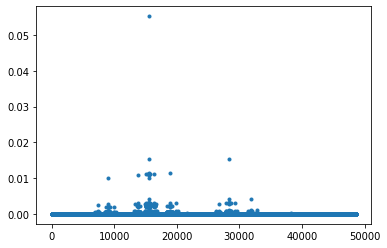

In [118]:
plt.plot(eigenvectors**2,'.')

[[ 0.09976522]
 [ 0.10443906]
 [ 0.10502312]
 [ 0.10510906]
 [ 0.10510906]
 [ 0.10502312]
 [ 0.10443906]
 [ 0.09976522]
 [-0.23496375]
 [ 0.12392735]
 [ 0.1070105 ]
 [ 0.10539766]
 [ 0.10517366]
 [ 0.10514405]
 [ 0.10517366]
 [ 0.10539766]
 [ 0.1070105 ]
 [ 0.12392735]]
[-8.53240697]


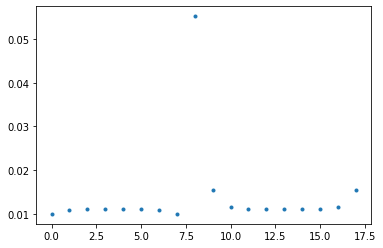

In [119]:
w = (eigenvectors**2 > 0.005).nonzero()[0]
print(eigenvectors[w])
print(-(0.1/2*16 - eigenvectors[w].sum()/eigenvectors[w[8]] +1))
plt.plot(eigenvectors[w]**2,'.')
eig18 = eigenvectors[w]

[[-0.11753851]
 [-0.12304458]
 [-0.12373028]
 [-0.12381738]
 [-0.12373028]
 [-0.12304458]
 [-0.11753851]
 [ 0.27682301]
 [-0.14600531]
 [-0.12607486]
 [-0.12417569]
 [-0.1239176 ]
 [-0.1239176 ]
 [-0.12417569]
 [-0.12607486]
 [-0.14600531]]
[-7.53754952]


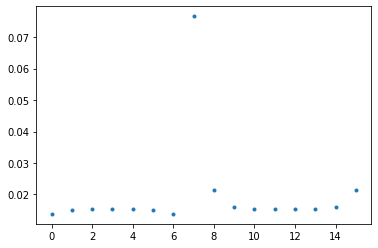

In [109]:
w = (eigenvectors**2 > 0.01).nonzero()[0]
print(eigenvectors[w])
print(-(0.1/2*14 - eigenvectors[w].sum()/eigenvectors[w[7]] +1))
plt.plot(eigenvectors[w]**2,'.')
eig16 = eigenvectors[w]

[[ 0.13847729]
 [ 0.14496142]
 [ 0.1457526 ]
 [ 0.1457526 ]
 [ 0.14496142]
 [ 0.13847729]
 [-0.32613868]
 [ 0.17201627]
 [ 0.14853642]
 [ 0.14630576]
 [ 0.1460428 ]
 [ 0.14630576]
 [ 0.14853642]
 [ 0.17201627]]
[-6.54269375]


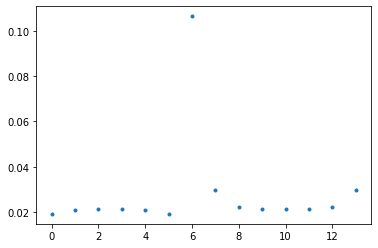

In [98]:
w = (eigenvectors**2 > 0.018).nonzero()[0]
print(eigenvectors[w])
print(-(0.1/2*12 - eigenvectors[w].sum()/eigenvectors[w[6]] +1))
plt.plot(eigenvectors[w]**2,'.')
eig14 = eigenvectors[w] 

[[ 0.1765774 ]
 [ 0.18347767]
 [ 0.18465064]
 [ 0.18871845]
 [ 0.24825081]
 [-0.4370058 ]
 [ 0.17153878]
 [ 0.18279935]
 [ 0.18431859]
 [ 0.18663268]
 [ 0.21372281]]
[-4.89510685]


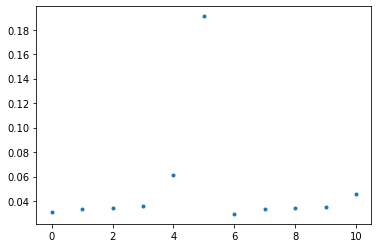

In [ ]:
w = (eigenvectors**2 > 0.02).nonzero()[0]
print(eigenvectors[w])
print(-(0.1/2*10 - eigenvectors[w].sum()/eigenvectors[w[5]] +1))
plt.plot(eigenvectors[w]**2,'.')
eig12 = eigenvectors[w] 

[-0.8487875]
[-0.84879265]
[-0.8487904]
[-0.8488092]
[-0.84878663]
[-0.84878779]
[-0.84878689]
[-0.84878927]
[-0.84878539]
[-0.8487808]


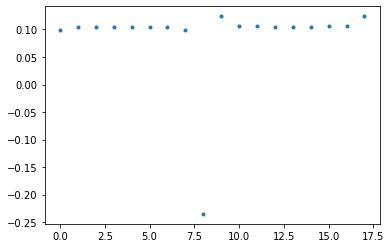

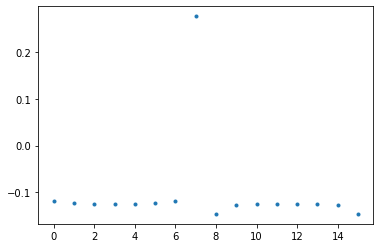

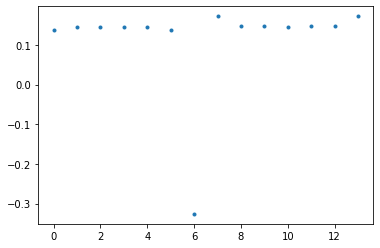

[[ 0.09976522]
 [ 0.10443906]
 [ 0.10502312]
 [ 0.10510906]
 [ 0.10510906]
 [ 0.10502312]
 [ 0.10443906]
 [ 0.09976522]
 [-0.23496375]
 [ 0.12392735]
 [ 0.1070105 ]
 [ 0.10539766]
 [ 0.10517366]
 [ 0.10514405]
 [ 0.10517366]
 [ 0.10539766]
 [ 0.1070105 ]
 [ 0.12392735]]


In [120]:
print(eig18[0]/eig16[0])
print(eig16[0]/eig14[0])
print(eig18[1]/eig16[1])
print(eig16[1]/eig14[1])
print(eig18[9]/eig16[8])
print(eig16[8]/eig14[7])
print(eig18[8]/eig16[7])
print(eig16[7]/eig14[6])
print(eig18[10]/eig16[9])
print(eig16[9]/eig14[8])
plt.plot(eig18,'.')
plt.show()
plt.plot(eig16,'.')
plt.show()
plt.plot(eig14,'.')
plt.show()
print(eig18)

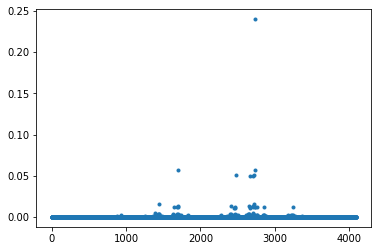

In [ ]:
e = torch.zeros(2**12)
i = torch.arange(924)
e[good_vectors] = torch.tensor(eigenvectors[i,0], dtype = torch.float)
plt.plot(e**2,'.')
#R8 = torch.tensor(R8, dtype = torch.float)
#print(e.dot(R8))

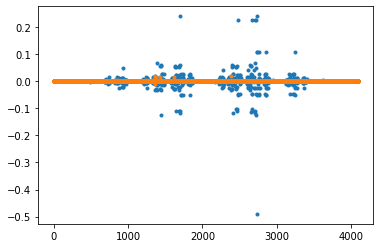

In [ ]:
nq =12
batch,num = permutations()
#print( num)
t = torch.zeros(2**12)
t[num] = e[num]
second = (e > 0.05).nonzero()
#print(second)
z = torch.zeros(2**12)
z[second] = e[second]
#t[1365] = 0
z[1365] = 0
plt.plot(e,'.')
plt.plot(t,'.')

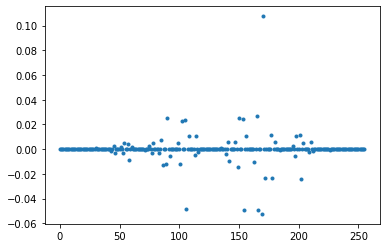

In [ ]:
plt.plot(e[2048 +1024: 2048 +1024 +256],'.')

In [ ]:
def permutations():
  main = torch.ones(nq)
  i = torch.arange(0,nq,2)
  main[i] = 0
  #print(main)
  a = 2**torch.arange(nq -1, -1,-1)
  num_main = (main*a).sum()
  #print(num_main)
  #new = torch.zeros(nq,nq-1)
  pm = torch.clone(main.reshape(1,nq).expand(nq-1,nq))
  for i in range(nq - 1):
    pm[i,i] = 1 - main[i]
    pm[i,i+1] = 1 - main[i+1]
  i = torch.arange(nq-1)
  res = torch.zeros(nq - 1, nq)
  ress = torch.zeros(nq - 1)
  res[i] = pm[i]*a 
  ress[i] = res[i].sum(dim = 1)
  batch = torch.cat((main.view(1,nq),pm), 0)
  ress = torch.cat((num_main.view(1),ress),0)
  t = ress.sort()
  i = torch.arange(nq)
  batch2 = torch.zeros(batch.shape[0], batch.shape[1])
  batch2[i,:] =  batch[t.indices[i],:]
  return batch2, t.values.long()

tensor([ 853, 1237, 1333, 1357, 1363, 1365, 1366, 1369, 1381, 1429, 1621, 2389])
tensor([[ 725],
        [ 821],
        [ 845],
        [ 851],
        [ 854],
        [ 857],
        [ 869],
        [ 917],
        [1205],
        [1229],
        [1235],
        [1238],
        [1241],
        [1253],
        [1325],
        [1331],
        [1334],
        [1337],
        [1355],
        [1358],
        [1365],
        [1370],
        [1379],
        [1382],
        [1385],
        [1421],
        [1427],
        [1430],
        [1433],
        [1445],
        [1589],
        [1613],
        [1619],
        [1622],
        [1625],
        [1637],
        [1685],
        [2261],
        [2357],
        [2381],
        [2387],
        [2390],
        [2393],
        [2405],
        [2453],
        [2645]])


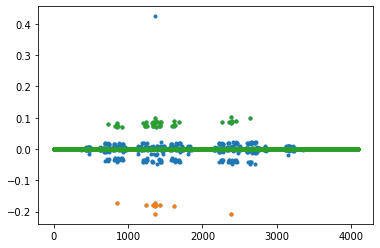

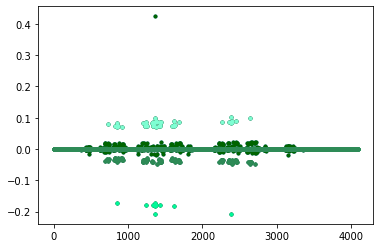

In [ ]:
nq =12
batch,num = permutations()
print( num)
t = torch.zeros(2**12)
t[num] = e[num]
second = (e > 0.05).nonzero()
print(second)
z = torch.zeros(2**12)
z[second] = e[second]
t[1365] = 0
z[1365] = 0
plt.plot(e,'.')
plt.plot(t,'.')
plt.plot(z,'.')
plt.show()
plt.plot(e,'.')
third = (e < -0.022).nonzero()
q = torch.zeros(2**12)
q[third] = e[third]
q[num] = 0
plt.plot(e,'.', color = 'darkgreen')
plt.plot(t,'.', color = 'mediumspringgreen')
plt.plot(z,'.', color = 'aquamarine')
plt.plot(q,'.', color = 'seagreen')
plt.savefig('Layers.pdf')


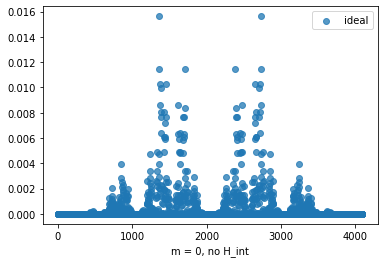

In [ ]:
fig, ax = plt.subplots()
e = torch.tensor(eigenvectors, dtype = torch.float32)
#print(e)
x = torch.arange(2**12)
i = torch.arange(eigenvectors.shape[0])
R = torch.zeros(2**12)
R[good_vectors] = e[i,0]
#ax.scatter(x, Rr**2, alpha = 1, label='ideal')
ax.scatter(x, R**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0, no H_int')
ax.legend()
plt.show()
#print(R.dot(Rr))

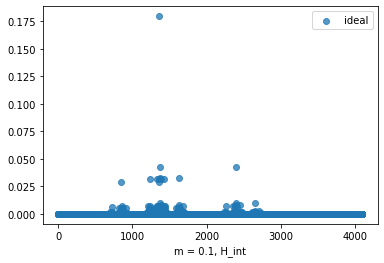

In [ ]:
fig, ax = plt.subplots()
e = torch.tensor(eigenvectors, dtype = torch.float32)
#print(e)
x = torch.arange(2**12)
i = torch.arange(eigenvectors.shape[0])
R = torch.zeros(2**12)
R[good_vectors] = e[i,0]
#ax.scatter(x, Rr**2, alpha = 1, label='ideal')
ax.scatter(x, R**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1, H_int')
ax.legend()
plt.show()
#print(R.dot(Rr))

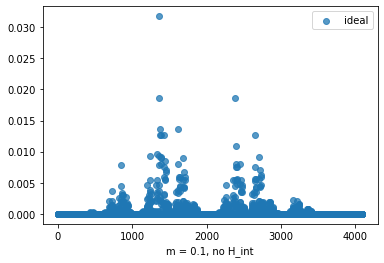

In [ ]:
fig, ax = plt.subplots()
e = torch.tensor(eigenvectors, dtype = torch.float32)
#print(e)
x = torch.arange(2**12)
i = torch.arange(eigenvectors.shape[0])
R = torch.zeros(2**12)
R[good_vectors] = e[i,0]
#ax.scatter(x, Rr**2, alpha = 1, label='ideal')
ax.scatter(x, R**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1, no H_int')
ax.legend()
plt.show()
#print(R.dot(Rr))

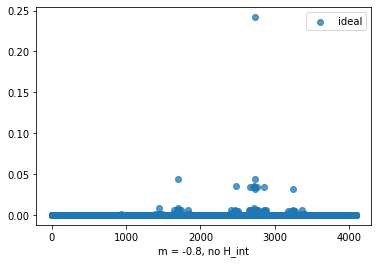

In [ ]:
fig, ax = plt.subplots()
e = torch.tensor(eigenvectors, dtype = torch.float32)
#print(e)
x = torch.arange(2**12)
i = torch.arange(eigenvectors.shape[0])
R = torch.zeros(2**12)
R[good_vectors] = e[i,0]
#ax.scatter(x, Rr**2, alpha = 1, label='ideal')
ax.scatter(x, R**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = -0.8, no H_int')
ax.legend()
plt.show()
#print(R.dot(Rr))

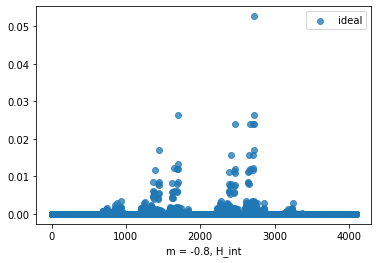

In [ ]:
fig, ax = plt.subplots()
e = torch.tensor(eigenvectors, dtype = torch.float32)
#print(e)
x = torch.arange(2**12)
i = torch.arange(eigenvectors.shape[0])
R = torch.zeros(2**12)
R[good_vectors] = e[i,0]
#ax.scatter(x, Rr**2, alpha = 1, label='ideal')
ax.scatter(x, R**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = -0.8, H_int')
ax.legend()
plt.show()
#print(R.dot(Rr))

In [ ]:
r = my_way[0:2**(number_of_qubits - 2)]
l = my_way[2**(number_of_qubits - 2): 2**(number_of_qubits - 1)]
t = my_way[ 2**(number_of_qubits - 1): 2**number_of_qubits]
print(r.norm(), l.norm(), t.norm())
one.append(r.norm())
two.append(l.norm())
three.append(t.norm())
print(one,two,three)

tensor(0.3231) tensor(0.8466) tensor(0.4229)
[array(0.3224049, dtype=float32), tensor(0.3234), tensor(0.3230), tensor(0.3232), tensor(0.3231), tensor(0.3231), tensor(0.3231), tensor(0.3231), tensor(0.3231), tensor(0.3231), tensor(0.3231)] [tensor(0.8467), tensor(0.8466), tensor(0.8466), tensor(0.8466), tensor(0.8466), tensor(0.8466), tensor(0.8466), tensor(0.8466), tensor(0.8466), tensor(0.8466), tensor(0.8466)] [tensor(0.4232), tensor(0.4228), tensor(0.4229), tensor(0.4229), tensor(0.4229), tensor(0.4229), tensor(0.4229), tensor(0.4229), tensor(0.4229), tensor(0.4229), tensor(0.4229)]


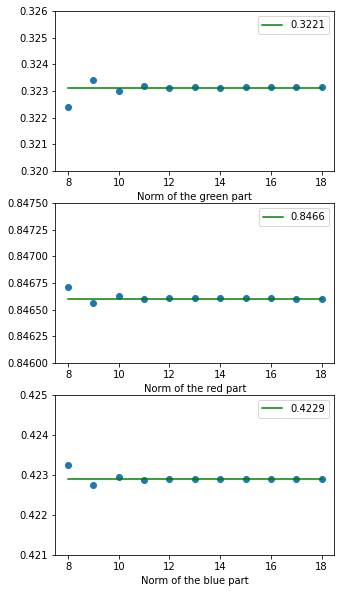

In [ ]:
y = 0.3231 +0*x
z = 0.8466 +0*x
w = 0.4229 +0*x
fig, ax = plt.subplots(3, 1, figsize = (5,10))
x = torch.arange(8,19,1)
ax[0].scatter(x, one, alpha = 1)
ax[0].plot(x,y , alpha = 1, color='g', label='0.3221')
ax[0].legend()
ax[1].scatter(x, two, alpha = 1)
ax[1].plot(x,z , alpha = 1, color='g', label='0.8466')
ax[1].legend()
ax[2].scatter(x, three, alpha = 1)
ax[2].plot(x,w , alpha = 1, color='g', label='0.4229')
ax[0].set_xlabel('Norm of the green part')
ax[1].set_xlabel('Norm of the red part')
ax[2].set_xlabel('Norm of the blue part')
ax[0].set_ylim(0.32, 0.326)
ax[1].set_ylim(0.846, 0.8475)
ax[2].set_ylim(0.421, 0.425)
plt.legend()
plt.show()


In [122]:
np.save('eig16_1st_ex_0.npy', eig16)

No handles with labels found to put in legend.


torch.FloatTensor


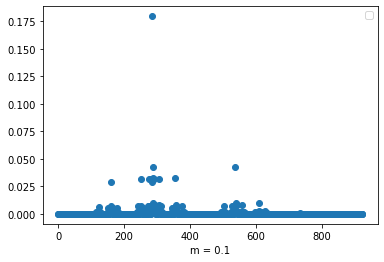

In [ ]:
#np.save('number_of_qubits_12.npy', eigenvectors)
import matplotlib.colors as mcolors

eigenvectors = torch.tensor(np.load('number_of_qubits_12_.npy')).float()
x = np.arange(0,eigenvectors.shape[0])
print(eigenvectors.type())
my_way = torch.zeros(2**12, dtype = torch.double)
#my_way[good_vectors] = eigenvectors[i]
a = my_way**2
fig, ax = plt.subplots()

ax.scatter(x, eigenvectors**2, alpha = 1)
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

In [ ]:
my_way_12 = torch.zeros(2**12, 1)
print(eigenvectors.shape)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_12[good_vectors] = eigenvectors[i]
x = torch.arange(2**12)

torch.Size([924, 1])


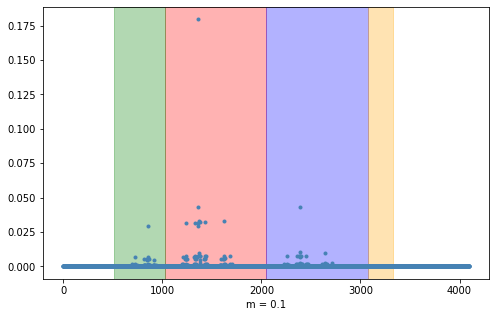

In [ ]:
fig, ax = plt.subplots()
ax.plot(x, my_way_12**2, '.', color = 'steelblue' )
ax.set_xlabel('m = 0.1')
plt.axvspan(1025, 2047, color='Red', alpha=0.3)
plt.axvspan(2049, 3072, color='Blue', alpha=0.3)
plt.axvspan(512, 1024, color='Green', alpha=0.3)
plt.axvspan(3072, 3072 + 256, color='Orange', alpha=0.3)
#ax.legend()
figure  =  plt.gcf()
figure.set_size_inches(8, 5)
plt.savefig('12nq.png')
plt.show()
#plt.savefig('12nq.pdf')

tensor(0.9997)
tensor(0.8466)
tensor(0.4213)


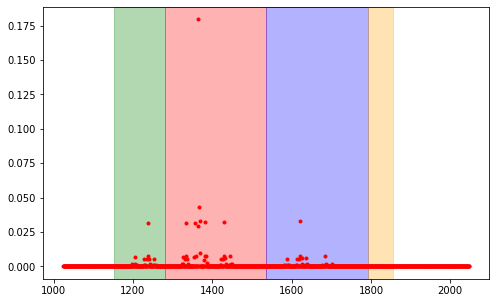

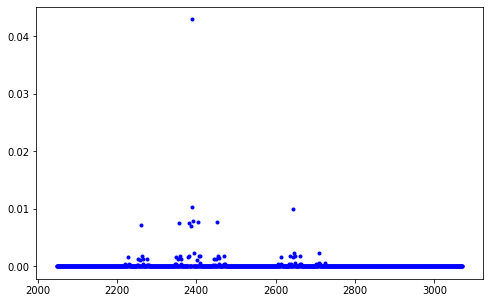

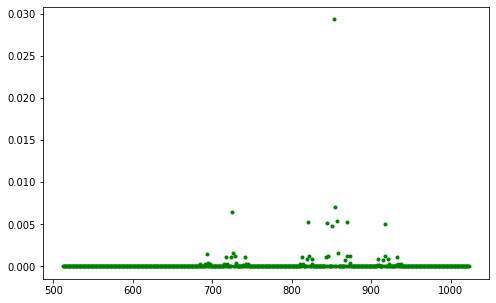

In [ ]:
print(my_way_12[512:3072 + 256].norm())
print(my_way_12[1024:2048].norm())
print(my_way_12[2048:3072].norm())
#plt.plot(my_way_12[512 - 128:512]**2,'.')
x = torch.arange(1024,1024 + 1024)
t = my_way_12[1024: 1024 + 1024]**2
plt.plot(x,t,'.', color = 'red')
plt.axvspan(1024 + 128, 1024 +256, color='Green', alpha=0.3)
plt.axvspan(1024 +256, 1024 +512, color='Red', alpha=0.3)
plt.axvspan(1024 +512,1024 + 512 + 256, color= 'Blue', alpha=0.3)
plt.axvspan(1024 +512 + 256, 1024+ 512 + 256+64, color= 'Orange', alpha=0.3)
figure  =  plt.gcf()
figure.set_size_inches(8, 5)
plt.savefig('12nqred.pdf')
plt.savefig('red.pdf')
plt.show()
x = torch.arange(1024 + 1024,1024 + 1024 + 1024)
t = my_way_12[1024 +1024: 1024 +1024 + 1024]**2
figure  =  plt.gcf()
figure.set_size_inches(8, 5)
plt.plot(x,t,'.', color = 'blue')
plt.show()
x = torch.arange(512,1024)
t = my_way_12[512:1024]**2
figure  =  plt.gcf()
figure.set_size_inches(8, 5)
plt.plot(x,t,'.', color = 'green')

In [ ]:
#np.save('number_of_qubits_12.npy', eigenvectors)
import matplotlib.colors as mcolors

eigenvectors = torch.tensor(np.load('number_of_qubits_12_.npy')).float()
x = np.arange(0,eigenvectors.shape[0])

ax.scatter(x, eigenvectors**2, alpha = 1)
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

No handles with labels found to put in legend.


In [ ]:
my_way_12_ = torch.zeros(2**12, 1)
print(eigenvectors.shape)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_12_[good_vectors] = eigenvectors[i]
x = torch.arange(2**12)

torch.Size([924, 1])


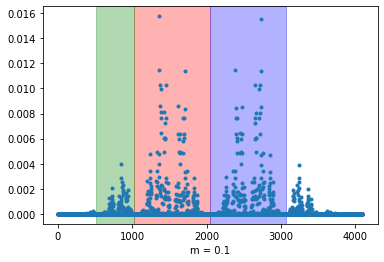

In [ ]:
fig, ax = plt.subplots()
ax.plot(x, my_way_12_**2, '.')
ax.set_xlabel('m = 0.1')
plt.axvspan(1025, 2047, color='red', alpha=0.3)
plt.axvspan(2049, 3072, color='blue', alpha=0.3)
plt.axvspan(512, 1024, color='green', alpha=0.3)
#ax.legend()
plt.show()

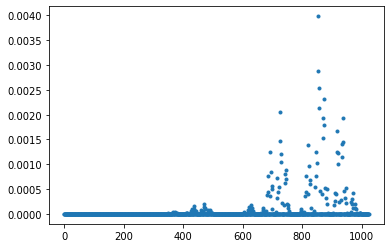

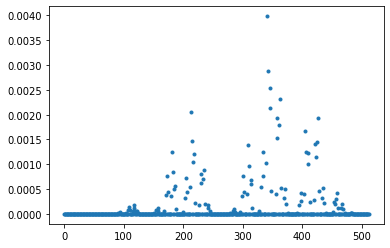

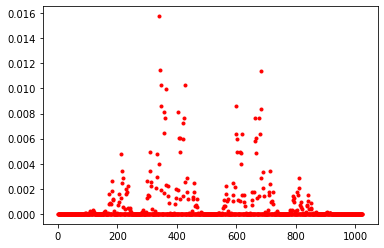

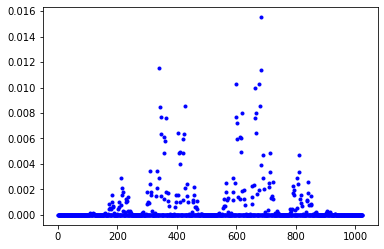

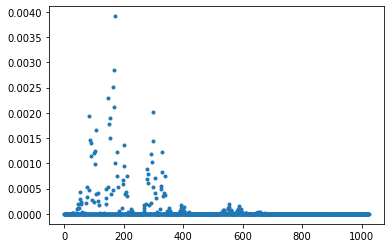

In [ ]:
r = my_way_12_[0:1024]
plt.plot(r**2,'.')
plt.show()
r = my_way_12_[512:1024]
plt.plot(r**2,'.')
plt.show()

r = my_way_12_[1024:2048]
plt.plot(r**2,'.', color='red')
plt.show()
r = my_way_12_[2048:3072]
plt.plot(r**2,'.', color='blue')
plt.show()
r = my_way_12_[3072:3072 + 1024]
plt.plot(r**2,'.')
plt.show()

In [ ]:
np.save('number_of_qubits_10_.npy', eigenvectors)

No handles with labels found to put in legend.


torch.FloatTensor


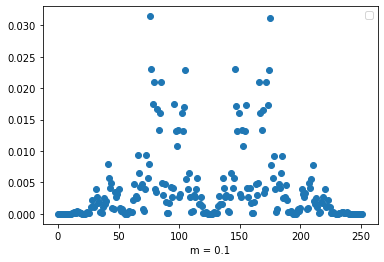

In [ ]:
import matplotlib.colors as mcolors

eigenvectors = torch.tensor(np.load('number_of_qubits_10_.npy')).float()
x = np.arange(0,eigenvectors.shape[0])
print(eigenvectors.type())
my_way = torch.zeros(2**10, dtype = torch.double)
#my_way[good_vectors] = eigenvectors[i]
a = my_way**2
fig, ax = plt.subplots()

ax.scatter(x, eigenvectors**2, alpha = 1)
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

In [ ]:
my_way_10_ = torch.zeros(2**10, 1)
print(eigenvectors.shape)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_10_[good_vectors] = eigenvectors[i]
x = torch.arange(2**10)

torch.Size([252, 1])


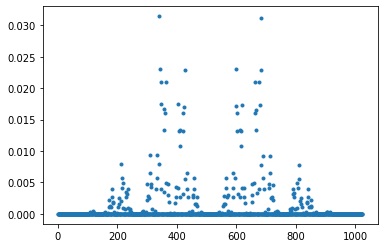

tensor(0.2599)
tensor(0.7579)
tensor(0.6524)
tensor(1.0000)


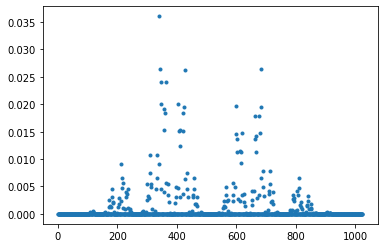

In [ ]:
fig, ax = plt.subplots()
ax.plot(my_way_10_**2, '.')
#ax.legend()
plt.show()
e = torch.zeros(2**10)
norm = my_way_12_[0:1024,0].norm()
print(norm)
e[:] = my_way_10_[:,0]

e = e/e.norm()
e[0:512] = e[0:512]/0.7078 * 0.7579
e[512:1024] = e[512:1024]/0.7064 * 0.6524
print(e[0:512].norm())
print(e[512:1024].norm())
print(e.norm())
plt.plot(e**2, '.')

tensor(0.7579)
tensor(0.6524)
tensor(0.7579)
tensor(0.6524)
tensor(0.9991)


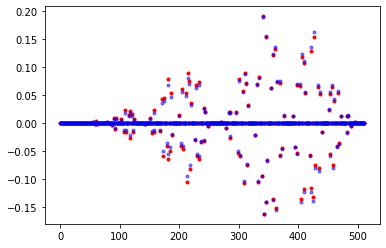

In [ ]:
r = my_way_12_[1024:2048]
r = r/r.norm()
print(r[0:512].norm())
print(r[512:1024].norm())

print(e[0:512].norm())
print(e[512:1024].norm())
plt.plot(r[0:512],'.', color='red')
plt.plot(e[0:512],'.', color='blue', alpha = 0.5)
print(r.view(-1).dot(e))

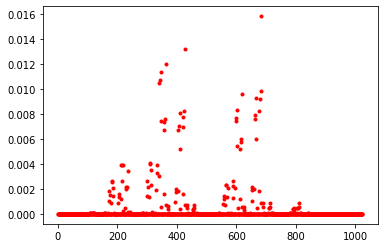

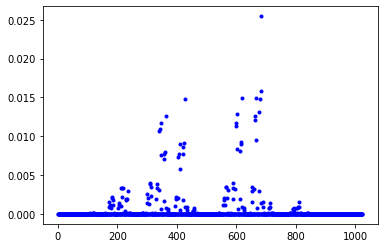

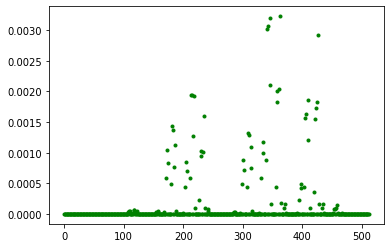

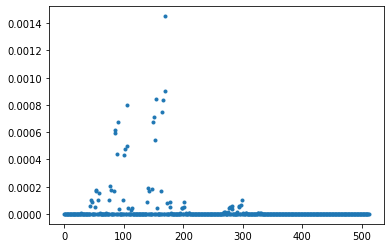

In [ ]:
r = my_way_12[1024:2048]
plt.plot(r**2,'.', color='red')
plt.show()
r = my_way_12[2048:3072]
plt.plot(r**2,'.', color='blue')
plt.show()
r = my_way_12[512:1024]
plt.plot(r**2,'.', color='green')
plt.show()
r = my_way_12[3072 :3072 + 512]
plt.plot(r**2,'.')
plt.show()

In [ ]:
np.save('number_of_qubits_10.npy', eigenvectors)

torch.FloatTensor


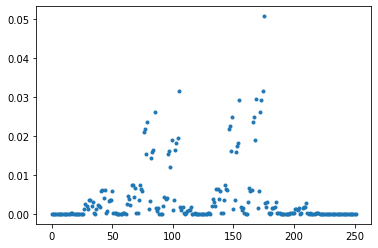

In [ ]:

eigenvectors = torch.tensor(np.load('number_of_qubits_10.npy')).float()
x = np.arange(0,eigenvectors.shape[0])
print(eigenvectors.type())
#my_way = torch.zeros(2**10, dtype = torch.double)
plt.plot(eigenvectors**2,'.')

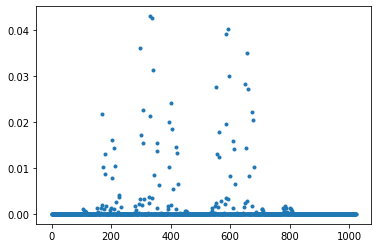

tensor(-3.3863)
tensor(-2.6333)


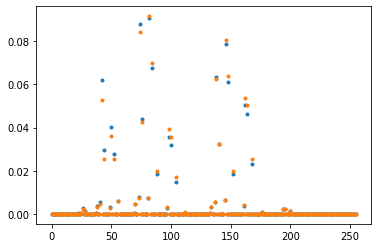

In [ ]:
H = Hamiltonian.Get_H(-0.7, 10)
eig_values, eig_vector = torch.eig(H, eigenvectors = True)#[0][:, 0]
eig_values = eig_values[:,0]
  #eig_vector = torch.eig(H, eigenvectors = True)[1]
k = torch.min(eig_values,0)[1]
R8 = eig_vector[:,k].reshape(2**10)
plt.plot(R8**2,'.')
plt.show()
print(eig_values.min())
plt.plot((R8[512:512 + 256]/R8[512:512 + 256].norm())**2,'.')

H = Hamiltonian.Get_H(-0.7, 8)
eig_values, eig_vector = torch.eig(H, eigenvectors = True)#[0][:, 0]
eig_values = eig_values[:,0]
  #eig_vector = torch.eig(H, eigenvectors = True)[1]
k = torch.min(eig_values,0)[1]
R8 = eig_vector[:,k].reshape(2**8)
plt.plot(R8**2,'.')
print(eig_values.min())

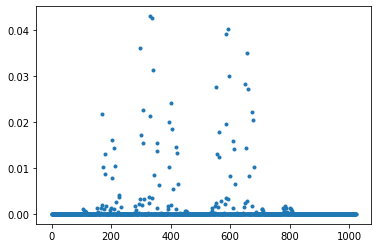

tensor(-3.3863)
tensor(-2.6333)


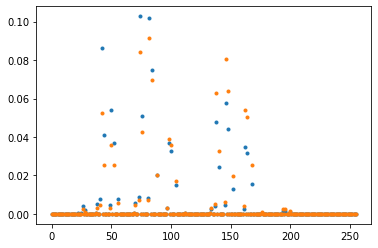

In [ ]:
H = Hamiltonian.Get_H(-0.7, 10)
eig_values, eig_vector = torch.eig(H, eigenvectors = True)#[0][:, 0]
eig_values = eig_values[:,0]
  #eig_vector = torch.eig(H, eigenvectors = True)[1]
k = torch.min(eig_values,0)[1]
R8 = eig_vector[:,k].reshape(2**10)
plt.plot(R8**2,'.')
plt.show()
print(eig_values.min())
plt.plot((R8[256:512]/R8[256:512].norm())**2,'.')

H = Hamiltonian.Get_H(-0.7, 8)
eig_values, eig_vector = torch.eig(H, eigenvectors = True)#[0][:, 0]
eig_values = eig_values[:,0]
  #eig_vector = torch.eig(H, eigenvectors = True)[1]
k = torch.min(eig_values,0)[1]
R8 = eig_vector[:,k].reshape(2**8)
plt.plot(R8**2,'.')
print(eig_values.min())

torch.Size([252, 1])
torch.Size([1024, 1]) torch.Size([1024, 1])
tensor(-0.9997)


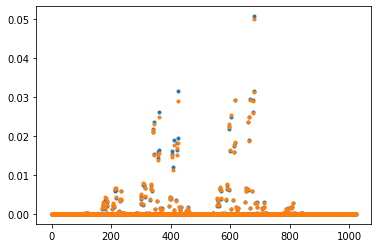

In [ ]:
my_way_10 = torch.zeros(2**10, 1)
print(eigenvectors.shape)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_10[good_vectors] = eigenvectors[i]
x = torch.arange(2**10)
plt.plot(x, my_way_10**2, '.')
e = torch.zeros(2**10,1)
print(e.shape, r.shape)
r = my_way_12[2048:3072]
#plt.plot(r**2,'.', color='blue')
#plt.show()
for i in x:
  e[i] = r[2**10 - i -1] 
e = e/e.norm()
#plt.plot(x, e**2, '.')
r = r/r.norm()
plt.plot(x, r**2, '.')
print(r.view(-1).dot(my_way_10.view(-1)))
#print(r.view(-1).dot(my_way_9.view(-1)))

In [ ]:
np.save('number_of_qubits_9_.npy', eigenvectors)
eigenvectors = torch.tensor(np.load('number_of_qubits_9_.npy')).float()

torch.FloatTensor


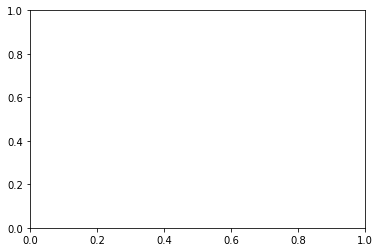

In [ ]:

eigenvectors = torch.tensor(np.load('number_of_qubits_9_.npy')).float()
x = np.arange(0,eigenvectors.shape[0])
print(eigenvectors.type())
my_way = torch.zeros(2**9, dtype = torch.double)
#my_way[good_vectors] = eigenvectors[i]
a = my_way**2
fig, ax = plt.subplots()


torch.Size([126, 1])
tensor(0.9753)


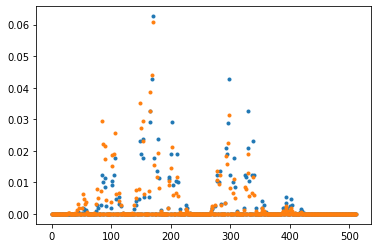

In [ ]:
my_way_9 = torch.zeros(2**9, 1)
print(eigenvectors.shape)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_9[good_vectors] = eigenvectors[i]
x = torch.arange(2**9)
plt.plot(x, my_way_9**2, '.')
e = torch.zeros(2**9,1)
r = my_way_12_[512:1024]
for i in x:
  e[i] = r[2**9 - i -1] 
e = e/e.norm()
plt.plot(x, e**2, '.')
r = r/r.norm()
#plt.plot(x, r**2, '.')
print(e.view(-1).dot(my_way_9.view(-1)))
#print(r.view(-1).dot(my_way_9.view(-1)))

In [ ]:
m = torch.clone(my_way_9)
for i in range(512):
  my_way_9[i] = m[511 - i]

tensor(0., dtype=torch.float64)
tensor(0., dtype=torch.float64)


NameError: ignored

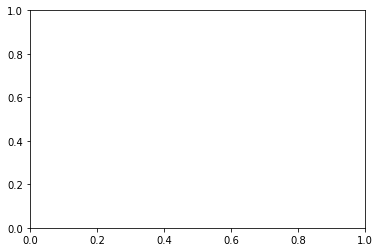

In [ ]:
r = my_way[1024:2048]

print(r.norm())
x = torch.arange(r.shape[0])
fig, ax = plt.subplots()
#r = r/r.norm()
t = r[0:512]
print(t.norm())
t = t/t.norm()
y = my_way_10[0:512] 
y = y/y.norm()
x = torch.arange(y.shape[0])
ax.scatter(x, t**2, alpha = 1, label='ideal')
#ax.scatter(x, y**2, alpha = 0.75, label='ideal')
#ax.scatter(x, my_way_9**2, alpha = 0.7, label='ideal')
#ax.scatter(x, r**2, alpha = 1, label='ideal')
#ax.scatter(x, my_way_10**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
# plt.axvspan(1024, 2048, color='red', alpha=0.3)
# plt.axvspan(2048, 3072, color='blue', alpha=0.3)
# plt.axvspan(512, 1024, color='green', alpha=0.3)
ax.legend()
plt.show()
print(t.reshape(-1).dot(y.reshape(-1)))

In [ ]:
t = r[0:500]
t.norm()

tensor(0.7847)

torch.Size([128])


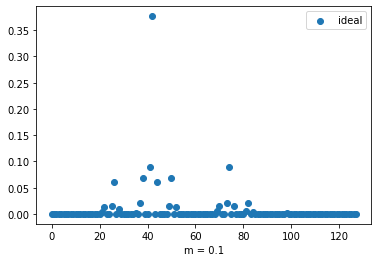

In [ ]:
import matplotlib.colors as mcolors
x = np.arange(0,eigenvectors.shape[0])
eigenvectors = torch.tensor(np.load('number_of_qubits_7.npy')).float()
print(eigenvectors.shape)
my_way = torch.zeros(2**7, dtype = torch.double)
#my_way[good_vectors] = eigenvectors[i]
a = my_way**2
fig, ax = plt.subplots()

ax.scatter(x, eigenvectors**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
my_way_7 = eigenvectors

torch.Size([256])


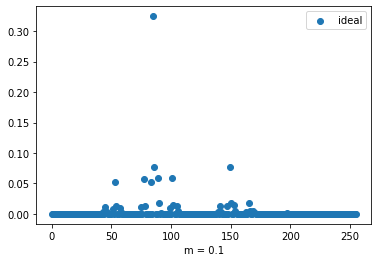

In [ ]:
#np.save('number_of_qubits_10.npy', eigenvectors)
import matplotlib.colors as mcolors
x = np.arange(0,eigenvectors.shape[0])
eigenvectors = torch.tensor(np.load('number_of_qubits_8.npy')).float()
print(eigenvectors.shape)
my_way = torch.zeros(2**8, dtype = torch.double)
#my_way[good_vectors] = eigenvectors[i]
a = my_way**2
fig, ax = plt.subplots()

ax.scatter(x, eigenvectors**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
my_way_8 = eigenvectors

torch.Size([256, 1])
tensor(0.3741)


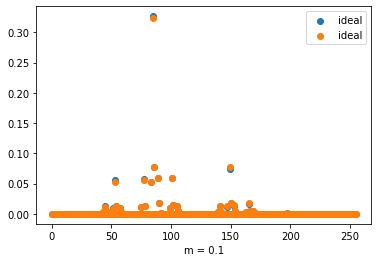

tensor(-0.9999)


In [ ]:
k = r[512:768]
print(k.shape)
x = torch.arange(2**8)
print(k.norm())
fig, ax = plt.subplots()
k = k/k.norm()
ax.scatter(x, k**2, alpha = 1, label='ideal')
ax.scatter(x, my_way_8**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
# plt.axvspan(1024, 2048, color='red', alpha=0.3)
# plt.axvspan(2048, 3072, color='blue', alpha=0.3)
# plt.axvspan(512, 1024, color='green', alpha=0.3)
ax.legend()
plt.show()
print(k.reshape(-1).dot(my_way_8.reshape(-1)))

torch.Size([256, 1])


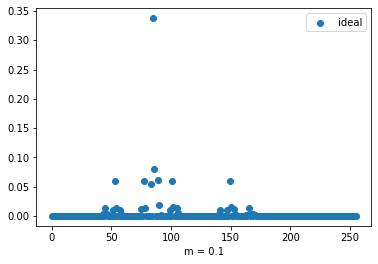

In [ ]:
l = r[256: 512]
print(l.shape)
x = torch.arange(2**8)

fig, ax = plt.subplots()
l = l/l.norm()
ax.scatter(x, l**2, alpha = 1, label='ideal')
#ax.scatter(x, my_way_10**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
# plt.axvspan(1024, 2048, color='red', alpha=0.3)
# plt.axvspan(2048, 3072, color='blue', alpha=0.3)
# plt.axvspan(512, 1024, color='green', alpha=0.3)
ax.legend()
plt.show()
#print(r.reshape(-1).dot(my_way_10.reshape(-1)))

tensor(0.4213)


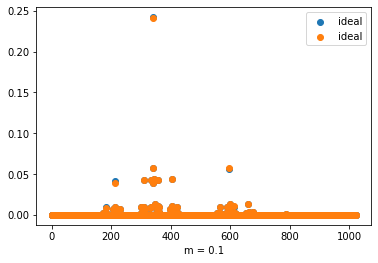

tensor(1.0000)


In [ ]:
r = my_way_12[2048:3072]
x = torch.arange(2**10)
print(r.norm())
fig, ax = plt.subplots()
r = r/r.norm()
ax.scatter(x, r**2, alpha = 1, label='ideal')
ax.scatter(x, my_way_10**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
# plt.axvspan(1024, 2048, color='red', alpha=0.3)
# plt.axvspan(2048, 3072, color='blue', alpha=0.3)
# plt.axvspan(512, 1024, color='green', alpha=0.3)
ax.legend()
plt.show()
print(r.reshape(-1).dot(my_way_10.reshape(-1)))

torch.Size([1024])


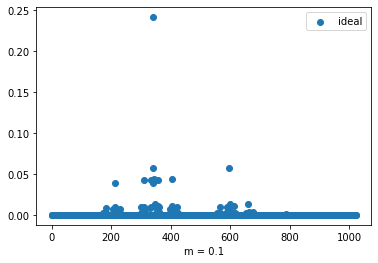

In [ ]:
#np.save('number_of_qubits_10.npy', eigenvectors)
import matplotlib.colors as mcolors
x = np.arange(0,eigenvectors.shape[0])
eigenvectors = torch.tensor(np.load('number_of_qubits_10.npy')).float()
print(eigenvectors.shape)
my_way = torch.zeros(2**10, dtype = torch.double)
#my_way[good_vectors] = eigenvectors[i]
a = my_way**2
fig, ax = plt.subplots()

ax.scatter(x, eigenvectors**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
my_way_10 = eigenvectors

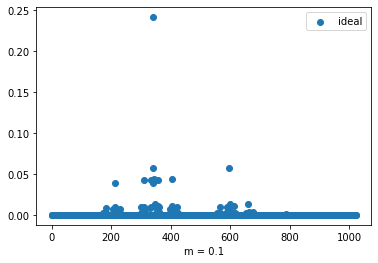

In [ ]:
my_way_10 = torch.zeros(2**10, 1)
i = torch.arange(math.ceil(good_vectors.shape[0]))
#eigenvectors = torch.tensor(eigenvectors).float()
my_way_10[good_vectors, 0] = eigenvectors[i,0]
x = torch.arange(2**10)

fig, ax = plt.subplots()

ax.scatter(x, my_way_10**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
#plt.axvspan(1024, 2048, color='red', alpha=0.3)
#plt.axvspan(2048, 3072, color='blue', alpha=0.3)
#plt.axvspan(512, 1024, color='green', alpha=0.3)
ax.legend()
plt.show()

torch.DoubleTensor


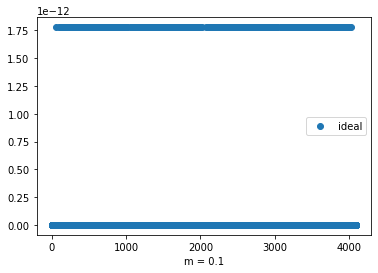

In [ ]:
import matplotlib.colors as mcolors
x = np.arange(0,2**12)
eigenvectors = torch.tensor(np.load('number_of_qubits_12.npy')).reshape(-1)
print(eigenvectors.type())
my_way = torch.zeros(2**12, dtype = torch.double)
my_way[good_vectors] = eigenvectors[i]
a = my_way**2
fig, ax = plt.subplots()

ax.scatter(x, a, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

In [ ]:
2**16

65536

In [ ]:
num_14 = torch.tensor(np.load('number_of_qubits_14.npy')).float()
num_16 = torch.tensor(np.load('number_of_qubits_16.npy')).float()
#net = torch.tensor(np.load('number_of_qubits_16_iter1499.npy')).float()
print(num_16.shape)
print(num_14.shape)

torch.Size([12870, 1])
torch.Size([3432, 1])


In [ ]:
my_way_14 = torch.zeros(2**14, 1)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_14[good_vectors, :] = num_14[i, :]

In [ ]:
my_way_16 = torch.zeros(2**16, 1)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_16[good_vectors, 0] = num_16[i, 0]

In [ ]:
net_way_16 = torch.zeros(2**16, 1)
i = torch.arange(math.ceil(good_vectors.shape[0]))
net_way_16[good_vectors, 0] = net[i, 0]
net_way_16 = net_way_16/net_way_16.norm()

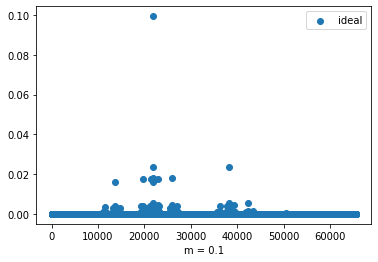

In [ ]:
x = torch.arange(my_way_16.shape[0])
fig, ax = plt.subplots()
ax.scatter(x, my_way_16**2, alpha = 1, label='ideal')
#ax.scatter(x, net_way_16**2, alpha = 0.75, label='net')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print()

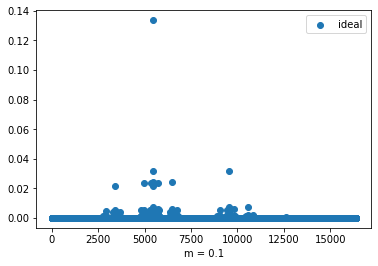

In [ ]:
x = torch.arange(my_way_14.shape[0])
fig, ax = plt.subplots()
ax.scatter(x, my_way_14**2, alpha = 1, label='ideal')
#ax.scatter(x, net_way_16**2, alpha = 0.75, label='net')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print()

In [ ]:
def CP_conj(batch):
    add = torch.clone(batch)
    CP_batch = torch.clone(batch)
    i = torch.arange(0,number_of_qubits/2,1).type(torch.LongTensor)
    j = torch.arange(number_of_qubits-1, number_of_qubits/2-1, -1).type(torch.LongTensor)
    CP_batch[:,i] = CP_batch[:,j]
    CP_batch[:,j] = add[:,i]
    add = torch.clone(CP_batch)

    CP_batch[add == 0] = 1
    CP_batch[add == 1] = 0
    return CP_batch

torch.Size([16384])
tensor(1.0000)


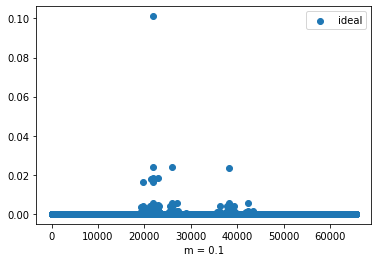

tensor([17877, 18093, 18099, 18101, 18102, 18105, 18123, 18125, 18126, 18131,
        18133, 18134, 18137, 18138, 18149]) ind
torch.Size([65536, 16])
tensor(53589.)
torch.Size([2176, 1]) CP shape
tensor([8., 8., 8.,  ..., 8., 8., 8.]) good
torch.Size([12870, 1])


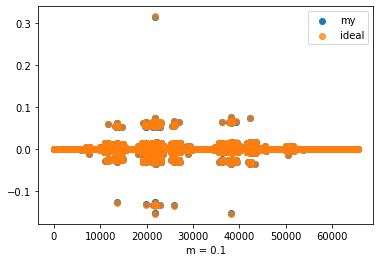

torch.Size([12870, 1])


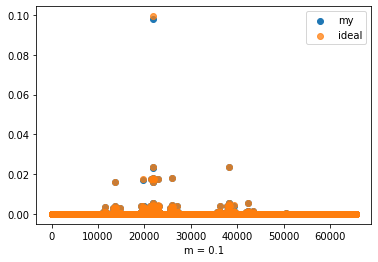

tensor(0.9931)


In [ ]:
start = 1365 - 341
R = my_way_14.reshape(-1)
#R = R/R.norm()
print(R.shape)
print(R.dot(my_way_14.view(-1)))
distr16 = torch.zeros(2**16)
ind = torch.arange(2**14)
distr16[ind + 2**14] = R[ind]*0.87
distr16[ind + 2**15] = -R[ind]*0.42

fig, ax = plt.subplots()
x = torch.arange(2**16)
ax.scatter(x, distr16**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

ind = (torch.abs(distr16) > 0.001).nonzero()
print(ind[0:15,0], 'ind')
print(basis.shape)

batch = basis[ind].view(-1, 16)

CP_batch = CP_conj(batch)
number_of_qubits = 16
a = 2**torch.arange(number_of_qubits -1, -1,-1)
CP_ind = CP_batch*a 
CP_ind = (CP_ind.sum(dim = 1)).view(CP_ind.shape[0], 1)


print(CP_ind.max())
print(CP_ind.shape, 'CP shape')
print(((basis[CP_ind.reshape(-1).numpy()].sum(1))), 'good')
distr16[CP_ind.numpy()] = distr16[ind]
distr16 = distr16/distr16.norm()
fig, ax = plt.subplots()

x = torch.arange(2**16)
print(num_16.shape)
ax.scatter(x, distr16, alpha = 1, label='my')
ax.scatter(x, my_way_16, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

fig, ax = plt.subplots()

x = torch.arange(2**16)
print(num_16.shape)
ax.scatter(x, distr16**2, alpha = 1, label='my')
ax.scatter(x, my_way_16**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print(my_way_16.view(-1).dot(distr16))


In [ ]:
17875, 17881, 18099, 18101, 18102, 18105, 18123, 18125, 18126, 18131,
        18133, 18134, 18137, 18138, 18149]

In [ ]:
print(my_way_16.shape)
r = my_way_16[2**13:2**14,0]
r = r/r.norm()
#r = my_way_16[2**14: 2**15,0]
print(r.shape, 2**13)

torch.Size([65536, 1])
torch.Size([8192]) 8192


In [ ]:
num_13 = torch.tensor(eigenvectors).float()

In [ ]:
my_way_13 = torch.zeros(2**13, 1)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_13[good_vectors, :] = num_13[i, :]

In [ ]:
rt = torch.clone(r)
i = torch.arange(2**13)
j = torch.arange(2**13-1,-1,-1)
r[i] = rt[j]

torch.Size([8192]) torch.Size([8192]) torch.Size([8192, 1])


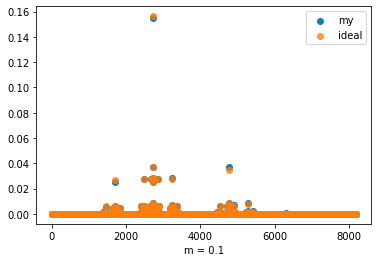

In [ ]:
fig, ax = plt.subplots()

x = torch.arange(r.shape[0])
print(x.shape, r.shape, my_way_13.shape)
ax.scatter(x, my_way_13**2, alpha = 1, label='my')
ax.scatter(x, r**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

In [ ]:
num_16 = torch.tensor(np.load('number_of_qubits_16.npy')).float()
num_18 = torch.tensor(np.load('number_of_qubits_18.npy')).float()
#net = torch.tensor(np.load('number_of_qubits_16_iter1499.npy')).float()
print(num_18.shape)
print(num_16.shape)

torch.Size([48620, 1])
torch.Size([12870, 1])


In [ ]:
my_way_16 = torch.zeros(2**16, 1)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_16[good_vectors, 0] = num_16[i, 0]

In [ ]:
my_way_18 = torch.zeros(2**18, 1)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_18[good_vectors, 0] = num_18[i, 0]

torch.Size([65536])


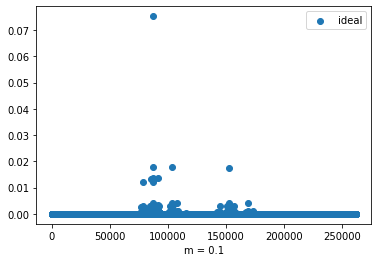

torch.Size([262144])
torch.Size([48620, 1])


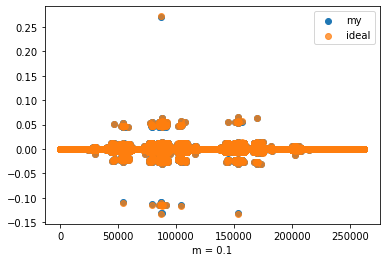

torch.Size([48620, 1])


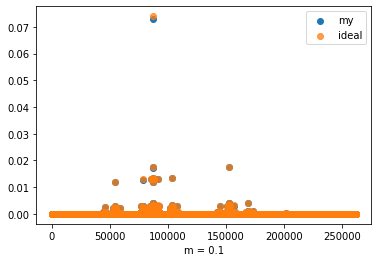

tensor(0.9932)


In [ ]:
start = 1365 - 341
R = my_way_16.reshape(-1)
print(R.shape)
distr18 = torch.zeros(2**18)
ind = torch.arange(2**16)
distr18[ind + 2**16] = R[ind]*0.87
distr18[ind + 2**17] = -R[ind]*0.42
fig, ax = plt.subplots()
x = torch.arange(2**18)
ax.scatter(x, distr18**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
ind = (torch.abs(distr18) > 0).nonzero()
print(distr18.shape)
batch = basis[ind].view(-1, 18)

CP_batch = CP_conj(batch)
number_of_qubits = 18
a = 2**torch.arange(number_of_qubits -1, -1,-1)
CP_ind = CP_batch*a 
CP_ind = (CP_ind.sum(dim = 1)).view(CP_ind.shape[0], 1)
distr18[CP_ind.numpy()] = distr18[ind]
distr18 = distr18/distr18.norm()
fig, ax = plt.subplots()

x = torch.arange(2**18)
print(num_18.shape)
ax.scatter(x, distr18, alpha = 1, label='my')
ax.scatter(x, my_way_18, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

fig, ax = plt.subplots()

x = torch.arange(2**18)
print(num_18.shape)
ax.scatter(x, distr18**2, alpha = 1, label='my')
ax.scatter(x, my_way_18**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print(my_way_18.view(-1).dot(distr18))
